In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

In [2]:
cdf= pd.read_csv('credit_card_customers.csv')
credf= pd.DataFrame(cdf)

credf.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
print(f"Number of rows: {credf.shape[0]} ")
print(f"Number of columns: {credf.shape[1]} ")

Number of rows: 10127 
Number of columns: 23 


In [4]:
credf.tail(20)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
10107,713924283,Attrited Customer,61,M,0,Graduate,Single,R60K - R80K,Blue,54,...,11859.0,1644,10215.0,0.866,8930,79,0.837,0.139,0.992680,0.007320
10108,714471183,Attrited Customer,47,M,4,Graduate,Divorced,R80K - R120K,Blue,39,...,17504.0,476,17028.0,0.892,10468,66,0.737,0.027,0.998160,0.001844
10109,780613758,Existing Customer,47,M,5,High School,Single,Less than R40K,Blue,35,...,4165.0,0,4165.0,0.813,17093,111,0.820,0.000,0.000896,0.999100
10110,718225683,Existing Customer,56,M,1,Graduate,Single,R80K - R120K,Silver,49,...,34516.0,1091,33425.0,0.640,15274,108,0.714,0.032,0.000097,0.999900
10111,710734308,Existing Customer,49,M,1,Graduate,Single,R60K - R80K,Blue,40,...,6481.0,1569,4912.0,0.692,15937,119,0.803,0.242,0.000284,0.999720
10112,708564858,Attrited Customer,33,M,2,College,Married,R120K +,Gold,20,...,34516.0,0,34516.0,1.004,9338,73,0.622,0.000,0.994380,0.005620
10113,713733633,Attrited Customer,27,M,0,High School,Divorced,R60K - R80K,Blue,36,...,13303.0,2517,10786.0,0.929,10219,85,0.809,0.189,0.993380,0.006620
10114,720841533,Existing Customer,29,M,0,Graduate,Married,Less than R40K,Blue,15,...,4700.0,0,4700.0,0.617,14723,96,0.655,0.000,0.000235,0.999770
10115,712210458,Existing Customer,38,M,1,Uneducated,Single,R40K - R60K,Blue,36,...,5639.0,1558,4081.0,0.614,16628,109,0.946,0.276,0.000174,0.999830
10116,714109308,Existing Customer,46,M,5,College,Single,R80K - R120K,Blue,36,...,13187.0,2241,10946.0,0.689,15354,112,0.931,0.170,0.000192,0.999810


In [5]:
credf.dtypes

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                            str
Customer_Age                                                                                                                            int64
Gender                                                                                                                                    str
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                           str
Marital_Status                                                                                                                            str
Income

In [6]:
credf.info()

<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                                                                                                                              Non-Null Count  Dtype  
---  ------                                                                                                                              --------------  -----  
 0   CLIENTNUM                                                                                                                           10127 non-null  int64  
 1   Attrition_Flag                                                                                                                      10127 non-null  str    
 2   Customer_Age                                                                                                                        10127 non-null  int64  
 3   Gender                                                                                      

In [18]:
credf.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [19]:
print(f"Arrition Flag: {credf['Attrition_Flag'].unique()} \n")
print(f"Education Level: {credf['Education_Level'].unique()} \n")
print(f"Marital Status: {credf['Marital_Status'].unique()} \n")
print(f"Income Category: {credf['Income_Category'].unique()} \n")
print(f"Card Category: {credf['Card_Category'].unique()} \n")
print(f"Gender: {credf['Gender'].unique()} \n")

print(f"Arrition Flag: {credf['CLIENTNUM'].unique()} \n")
print(f"Arrition Flag: {credf['Customer_Age'].unique()} \n")
print(f"Arrition Flag: {credf['Dependent_count'].unique()} \n")
print(f"Arrition Flag: {credf['Months_on_book'].unique()} \n")
print(f"Arrition Flag: {credf['Credit_Limit'].unique()} \n")

Arrition Flag: <StringArray>
['Existing Customer', 'Attrited Customer']
Length: 2, dtype: str 

Education Level: <StringArray>
[  'High School',      'Graduate',    'Uneducated',       'Unknown',
       'College', 'Post-Graduate',     'Doctorate']
Length: 7, dtype: str 

Marital Status: <StringArray>
['Married', 'Single', 'Unknown', 'Divorced']
Length: 4, dtype: str 

Income Category: <StringArray>
[   'R60K - R80K', 'Less than R40K',   'R80K - R120K',    'R40K - R60K',
        'R120K +',        'Unknown']
Length: 6, dtype: str 

Card Category: <StringArray>
['Blue', 'Gold', 'Silver', 'Platinum']
Length: 4, dtype: str 

Gender: <StringArray>
['M', 'F']
Length: 2, dtype: str 

Arrition Flag: [768805383 818770008 713982108 ... 716506083 717406983 714337233] 

Arrition Flag: [45 49 51 40 44 32 37 48 42 65 56 35 57 41 61 47 62 54 59 63 53 58 55 66
 50 38 46 52 39 43 64 68 67 60 73 70 36 34 33 26 31 29 30 28 27] 

Arrition Flag: [3 5 4 2 0 1] 

Arrition Flag: [39 44 36 34 21 46 27 31 54 30 

In [20]:
print(credf.nunique())

CLIENTNUM                                                                                                                             10127
Attrition_Flag                                                                                                                            2
Customer_Age                                                                                                                             45
Gender                                                                                                                                    2
Dependent_count                                                                                                                           6
Education_Level                                                                                                                           7
Marital_Status                                                                                                                            4
Income_Category     

In [21]:
subset_credf= credf.iloc[:, 1:-7] ##Discards the last seven columns and the first
subset_credf

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
0,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,5,1,3,12691.0,777,11914.0
1,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,6,1,2,8256.0,864,7392.0
2,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,4,1,0,3418.0,0,3418.0
3,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,3,4,1,3313.0,2517,796.0
4,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,5,1,0,4716.0,0,4716.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,Existing Customer,50,M,2,Graduate,Single,R40K - R60K,Blue,40,3,2,3,4003.0,1851,2152.0
10123,Attrited Customer,41,M,2,Unknown,Divorced,R40K - R60K,Blue,25,4,2,3,4277.0,2186,2091.0
10124,Attrited Customer,44,F,1,High School,Married,Less than R40K,Blue,36,5,3,4,5409.0,0,5409.0
10125,Attrited Customer,30,M,2,Graduate,Unknown,R40K - R60K,Blue,36,4,3,3,5281.0,0,5281.0


The average open to buy column refers to the average amount of available credit on a credit card holder's account at any time

In [22]:
subset_credf.describe(include = 'all')

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
count,10127,10127.000000,10127,10127.000000,10127,10127,10127,10127,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
unique,2,NaN,2,NaN,7,4,6,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Existing Customer,NaN,F,NaN,Graduate,Married,Less than R40K,Blue,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,8500,NaN,5358,NaN,3128,4687,3561,9436,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,46.325960,NaN,2.346203,NaN,NaN,NaN,NaN,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637
std,NaN,8.016814,NaN,1.298908,NaN,NaN,NaN,NaN,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324
min,NaN,26.000000,NaN,0.000000,NaN,NaN,NaN,NaN,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000
25%,NaN,41.000000,NaN,1.000000,NaN,NaN,NaN,NaN,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000
50%,NaN,46.000000,NaN,2.000000,NaN,NaN,NaN,NaN,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000
75%,NaN,52.000000,NaN,3.000000,NaN,NaN,NaN,NaN,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000


This means that the largest percentage of the education level of credit card holders are Graduates 3128/10127

In [23]:
subset_credf.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
0,Existing Customer,45,M,3,High School,Married,R60K - R80K,Blue,39,5,1,3,12691.0,777,11914.0
1,Existing Customer,49,F,5,Graduate,Single,Less than R40K,Blue,44,6,1,2,8256.0,864,7392.0
2,Existing Customer,51,M,3,Graduate,Married,R80K - R120K,Blue,36,4,1,0,3418.0,0,3418.0
3,Existing Customer,40,F,4,High School,Unknown,Less than R40K,Blue,34,3,4,1,3313.0,2517,796.0
4,Existing Customer,40,M,3,Uneducated,Married,R60K - R80K,Blue,21,5,1,0,4716.0,0,4716.0


In [24]:
##Determine and display the percentage of customers who receive an income of R120K + or more both uneducated and those with a PHD
uneducated_level = subset_credf[ subset_credf['Education_Level'] =='Uneducated' ]

high_earner_uneducated = uneducated_level[ uneducated_level['Income_Category'] =='R120K +']

PHD_level = subset_credf[ subset_credf['Education_Level'] =='Doctorate' ]
high_earner_PHD = PHD_level[ PHD_level['Income_Category'] =='R120K +']


print( len(high_earner_uneducated)/len(uneducated_level) * 100)
print( len(high_earner_PHD)/len(PHD_level) *100)

8.002689979825153
8.2039911308204


In [25]:
subset_credf['Education_Level'].unique()

<StringArray>
[  'High School',      'Graduate',    'Uneducated',       'Unknown',
       'College', 'Post-Graduate',     'Doctorate']
Length: 7, dtype: str

In [26]:
# 1. Define the high income category string based on the dataset values
high_income = 'R120K +'

# 2. Function to calculate percentage for specific education levels
def get_high_income_pct(edu_level):
    # Filter for the specific education group
    group = subset_credf[subset_credf['Education_Level'] == edu_level]
    
    # Calculate how many in that group earn R120K+
    high_earners = group[group['Income_Category'] == high_income]
    
    # Return percentage
    if len(group) > 0:
        return (len(high_earners) / len(group)) * 100
    return 0

# 3. Calculate and display results
uneducated_pct = get_high_income_pct('Uneducated')
doc_pct = get_high_income_pct('Doctorate')

print(f"Percentage of Uneducated customers earning R120K+: {uneducated_pct:.2f}%")
print(f"Percentage of Doctorate (PhD) customers earning R120K+: {doc_pct:.2f}%")

Percentage of Uneducated customers earning R120K+: 8.00%
Percentage of Doctorate (PhD) customers earning R120K+: 8.20%


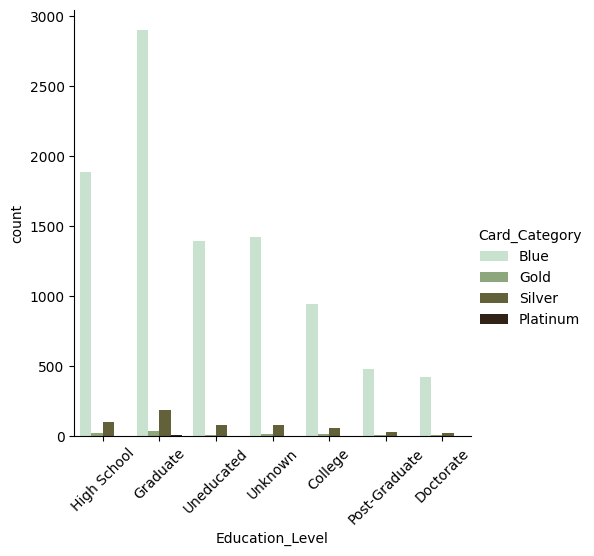

In [27]:
##Create a category plot that shows the number of customers belonging to a specific card category for each Education Level

sns.catplot(data = subset_credf, x='Education_Level',hue='Card_Category',kind="count",palette="ch:25")
plt.xticks(rotation = 45)
plt.show()

Analysis of the Plot
For the discussion part of the question, you can deduce the following from the graph:

Dominant Category: Across all education levels, the Blue card category is significantly more common than Gold, Silver, or Platinum.

Highest Engagement: Customers with a Graduate level of education represent the largest group of cardholders in this dataset.

Rare Categories: The Platinum card category is the least frequent and is almost invisible across several education levels, such as Doctorate or Post-Graduate.

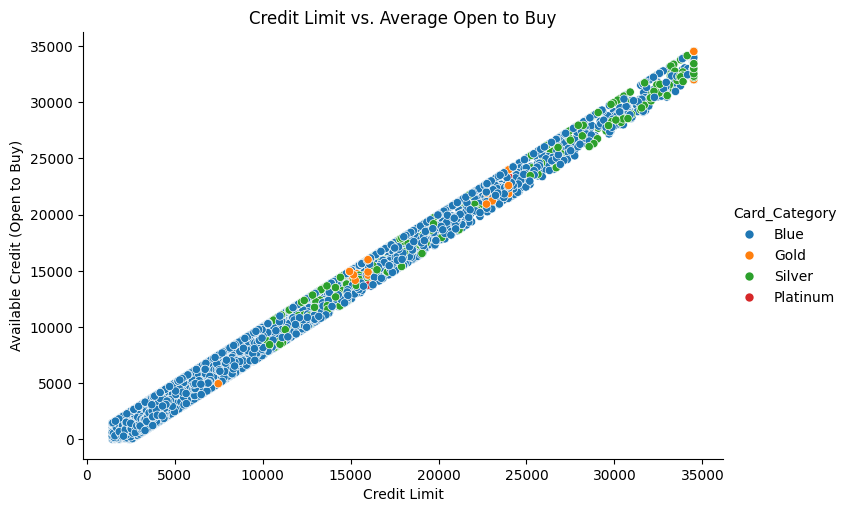

In [28]:
sns.relplot(data= subset_credf , x='Credit_Limit',y='Avg_Open_To_Buy',kind ='scatter',hue='Card_Category', aspect=1.5)
plt.title("Credit Limit vs. Average Open to Buy")
plt.xlabel("Credit Limit")
plt.ylabel("Available Credit (Open to Buy)")
plt.show()

Discussion:

Linear Relationship: There is a perfect positive linear correlation between these two variables. As the Credit_Limit increases, the Avg_Open_To_Buy increases at the same rate.

Interpretation: This suggests that most customers in this specific dataset are not utilizing a large portion of their credit, as their available credit remains almost identical to their total limit.

Tier Clustering: Higher card categories like Gold and Platinum are clustered at the top end of the credit limit spectrum (30,000+).

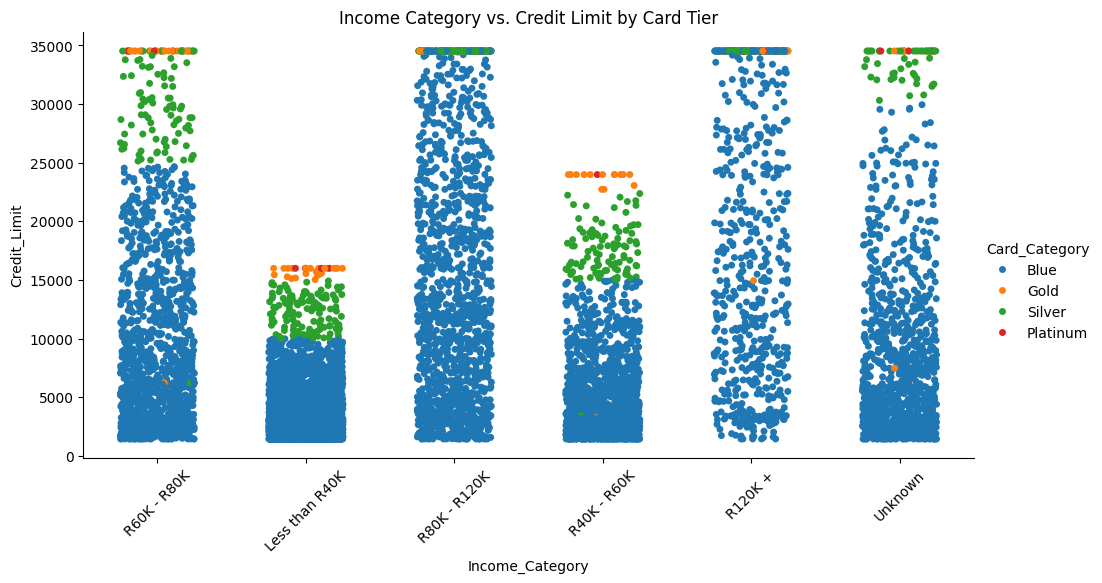

In [29]:
# Create a plot between Income Category and Credit Limit
# We use hue='Card_Category' to distinguish the card tiers
sns.catplot(data=subset_credf, x='Income_Category', y='Credit_Limit', 
            hue='Card_Category', kind='strip', aspect=2, jitter=0.25)

# Improve layout
plt.xticks(rotation=45)
plt.title("Income Category vs. Credit Limit by Card Tier")
plt.show()

Discussion:

Income Caps: Customers in the "Less than R40K" income bracket have a much lower maximum credit limit (capped around 15,000) compared to higher income brackets like "R120K +", which reach the 35,000 ceiling.

Card Distribution: The Blue card category is widespread across all income levels. However, the higher-tier cards (Silver and Gold) become significantly more frequent as the income level rises.

Ceiling Effect: There is a clear "ceiling" at the 35,000 mark where many high-income or high-tier cardholders are grouped, regardless of their specific income category.

In [30]:
subset_credf['Attrition_Flag'].value_counts()

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64

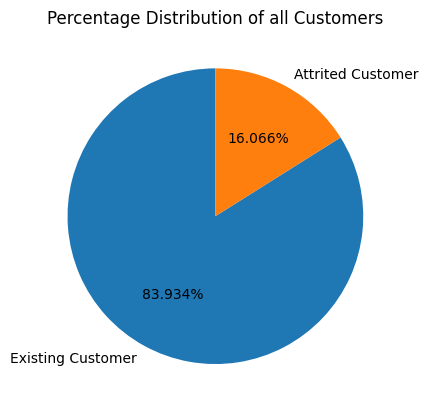

In [31]:
all_cust=subset_credf['Attrition_Flag'].value_counts()

plt.pie(all_cust.to_list(),labels=all_cust.index,autopct = '%.3f%%', startangle=90)
plt.title('Percentage Distribution of all Customers')
plt.show()

In [32]:
##Use an undersampling technique to balance the attrition flag column
from sklearn.utils import resample

# 1. Separate the majority and minority classes
df_majority = subset_credf[subset_credf['Attrition_Flag'] == 'Existing Customer']
df_minority = subset_credf[subset_credf['Attrition_Flag'] == 'Attrited Customer']

# 2. Undersample the majority class
df_majority_downsampled = resample(df_majority, 
                                 replace=False,    # sample without replacement
                                 n_samples=1627,   # match minority class size
                                 random_state=42)  # for reproducible results

# 3. Combine them into the new 'customers_resampled' dataframe
customers_resampled = pd.concat([df_majority_downsampled, df_minority])

# Show changes as required by the test
print(customers_resampled['Attrition_Flag'].value_counts())

Attrition_Flag
Existing Customer    1627
Attrited Customer    1627
Name: count, dtype: int64


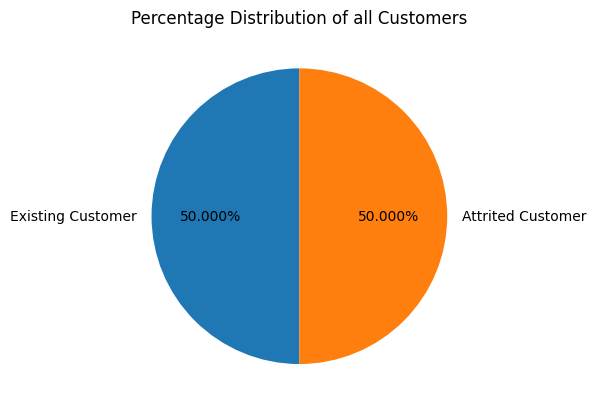

In [33]:
all_cust=customers_resampled['Attrition_Flag'].value_counts()


plt.pie(all_cust.to_list(),labels=all_cust.index,autopct = '%.3f%%', startangle=90)
plt.title('Percentage Distribution of all Customers')
plt.show()

In [ ]:
##Oversampling example(for reference)
from sklearn.utils import resample

# 1. Separate the classes
df_majority = customers[customers['Attrition_Flag'] == 'Existing Customer']
df_minority = customers[customers['Attrition_Flag'] == 'Attrited Customer']

# 2. Oversample the minority class
df_minority_upsampled = resample(df_minority, 
                                 replace=True,      # Sample with replacement (duplicates data)
                                 n_samples=8500,    # Match the majority class size
                                 random_state=42)

# 3. Combine back into 'customers_resampled'
customers_resampled = pd.concat([df_majority, df_minority_upsampled])

# Show changes for 2.11
print(customers_resampled['Attrition_Flag'].value_counts())

In [34]:
customers_resampled.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
7304,Existing Customer,53,F,3,Unknown,Married,R40K - R60K,Blue,46,6,3,1,2192.0,1146,1046.0
8014,Existing Customer,45,F,2,College,Unknown,Less than R40K,Blue,29,2,2,3,1438.3,0,1438.3
8271,Existing Customer,40,M,2,College,Single,R60K - R80K,Blue,28,1,2,3,10880.0,2025,8855.0
6408,Existing Customer,53,M,4,College,Single,R80K - R120K,Silver,48,5,1,2,34516.0,800,33716.0
7379,Existing Customer,45,F,4,Graduate,Married,Less than R40K,Blue,41,5,1,2,1927.0,1337,590.0


In [38]:
label_Encoder = LabelEncoder()

customers_resampled['Attrition_Flag'] = label_Encoder.fit_transform(customers_resampled['Attrition_Flag'])
customers_resampled['Gender'] = label_Encoder.fit_transform(customers_resampled['Gender'])


customers_resampled.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
7304,1,53,0,3,Unknown,Married,R40K - R60K,Blue,46,6,3,1,2192.0,1146,1046.0
8014,1,45,0,2,College,Unknown,Less than R40K,Blue,29,2,2,3,1438.3,0,1438.3
8271,1,40,1,2,College,Single,R60K - R80K,Blue,28,1,2,3,10880.0,2025,8855.0
6408,1,53,1,4,College,Single,R80K - R120K,Silver,48,5,1,2,34516.0,800,33716.0
7379,1,45,0,4,Graduate,Married,Less than R40K,Blue,41,5,1,2,1927.0,1337,590.0


In [42]:
eduLevel_vectors = pd.get_dummies(customers_resampled['Education_Level'],dtype=int)
marital_status_vectors = pd.get_dummies(customers_resampled['Marital_Status'],dtype=int)
card_Category_vectors = pd.get_dummies(customers_resampled['Card_Category'],dtype=int)
IncomeCategory_vectors = pd.get_dummies(customers_resampled['Income_Category'],dtype=int)

customers_resampled.drop(['Education_Level','Marital_Status','Card_Category','Income_Category'],axis=1,inplace=True)
customers_resampled.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy
7304,1,53,0,3,46,6,3,1,2192.0,1146,1046.0
8014,1,45,0,2,29,2,2,3,1438.3,0,1438.3
8271,1,40,1,2,28,1,2,3,10880.0,2025,8855.0
6408,1,53,1,4,48,5,1,2,34516.0,800,33716.0
7379,1,45,0,4,41,5,1,2,1927.0,1337,590.0


In [43]:
customers_resampled= pd.concat([customers_resampled,eduLevel_vectors,marital_status_vectors,card_Category_vectors,IncomeCategory_vectors],axis=1)

In [44]:
customers_resampled.head()

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,...,Blue,Gold,Platinum,Silver,Less than R40K,R120K +,R40K - R60K,R60K - R80K,R80K - R120K,Unknown
7304,1,53,0,3,46,6,3,1,2192.0,1146,...,1,0,0,0,0,0,1,0,0,0
8014,1,45,0,2,29,2,2,3,1438.3,0,...,1,0,0,0,1,0,0,0,0,0
8271,1,40,1,2,28,1,2,3,10880.0,2025,...,1,0,0,0,0,0,0,1,0,0
6408,1,53,1,4,48,5,1,2,34516.0,800,...,0,0,0,1,0,0,0,0,1,0
7379,1,45,0,4,41,5,1,2,1927.0,1337,...,1,0,0,0,1,0,0,0,0,0


In [45]:
from sklearn.model_selection import train_test_split

X = customers_resampled.drop(['Attrition_Flag'],axis = 1)
y= customers_resampled['Attrition_Flag'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 13)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)
X_train = scaler.transform(X_train)
scaler.fit(X_test)
X_test = scaler.transform(X_test)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2603, 31)
(2603,)
(651, 31)
(651,)


KNN(acc): 0.587778 (0.016605)
KNN(f1): 0.587136 (0.016787)


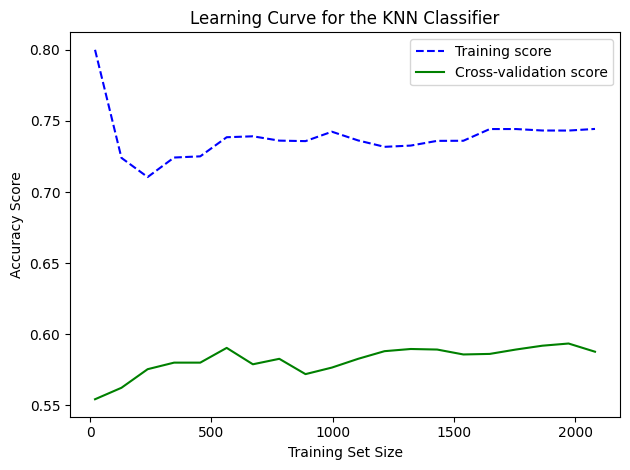

LR(acc): 0.707635 (0.012158)
LR(f1): 0.707596 (0.012144)


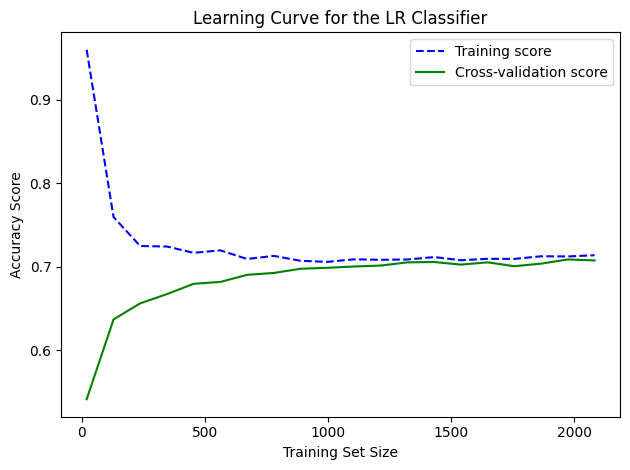

SVC(acc): 0.695721 (0.016100)
SVC(f1): 0.695574 (0.016046)


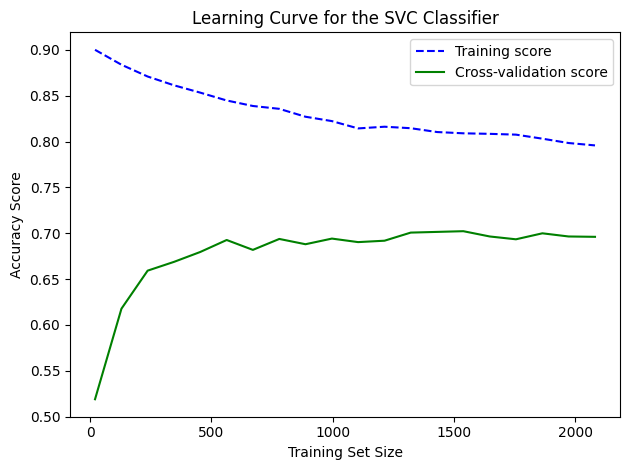

In [49]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve

from sklearn.metrics import f1_score
from sklearn.metrics import make_scorer

models = []

models.append(('KNN',KNeighborsClassifier()))
models.append(('LR',LogisticRegression(max_iter=1000)))
models.append(('SVC',SVC(gamma='auto')))


results = []
names =[]

f1 = make_scorer(f1_score,average = 'weighted')

for name,model in models:
    kfold =KFold(n_splits = 5,random_state=13,shuffle= True)
    cv_results = cross_val_score(model,X_train,y_train,cv=kfold,scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    msg='%s(acc): %f (%f)' % (name,cv_results.mean(),cv_results.std())
    print(msg)
    cv_results = cross_val_score(model, X_train, y_train, cv = kfold, scoring = f1)
    results.append(cv_results)
    names.append(name)
    msg = '%s(f1): %f (%f)' % (name, cv_results.mean(), cv_results.std())
    print(msg)
    train_sizes, train_scores, validation_scores = learning_curve(estimator = model,
                                                              X = X_train,
                                                              y = y_train,
                                                              train_sizes = np.linspace(0.01, 1.0, 20),
                                                              cv = kfold,
                                                              scoring = 'accuracy', shuffle = True)
    mean_training = np.mean(train_scores, axis=1)
    mean_testing = np.mean(validation_scores, axis=1)


    
    plt.plot(train_sizes, mean_training, '--', color = "b",  label = "Training score")
    plt.plot(train_sizes, mean_testing, color = "g", label = "Cross-validation score")
    plt.title(f"Learning Curve for the " + name + " Classifier")
    plt.xlabel("Training Set Size"), plt.ylabel("Accuracy Score"), plt.legend(loc = "best")
    plt.tight_layout()
    plt.show()

In [50]:
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)
predictions = model.predict(X_test)

print(metrics.accuracy_score(predictions,y_test))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

0.7588325652841782
[[234  73]
 [ 84 260]]
              precision    recall  f1-score   support

           0       0.74      0.76      0.75       307
           1       0.78      0.76      0.77       344

    accuracy                           0.76       651
   macro avg       0.76      0.76      0.76       651
weighted avg       0.76      0.76      0.76       651

